# 05 · Bulletin 17C examples 2 and 4

Orestimba Creek tests low floods and zeros; Arkansas River at Pueblo tests
historical event intervals and long perception windows. The four saved app
analyses pair two inputs with MVN/linked-MVN and bias-corrected bootstrap
uncertainty. BestFit fits LP-III by GMM here; these are confidence intervals,
not Bayesian posterior credible intervals.
Restart Kernel and Run All constructs and runs all four analyses.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime
from Numerics.Data import ProbabilityOrdinates
from Numerics.Distributions import UnivariateDistributionType, Uniform
from RMC.BestFit.Models import (DataFrame, ExactData, ExactSeries, IntervalData,
                                ThresholdData, Bulletin17CDistribution)
from RMC.BestFit.Analyses import Bulletin17CAnalysis, UncertaintyMethod
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Reconstruct the two original evidence frames

Example 2 includes 82 annual peaks with 12 zeros; the source flags 30 low
observations at 782 cfs. Example 4 has 81 exact peaks, four historical
intervals and four perception windows reaching back to 1165. Preserve
IsLowOutlier and NumberAbove; neither is an extra fabricated annual peak.

In [3]:
raw = load_raw("bulletin-17c-examples")
input_names = ["Example #2 - Data", "Example #4 - Data"]
frames = {}
for input_name in input_names:
    observed = raw["inputs"][input_name]
    frame = DataFrame()
    frame.ExactSeries = ExactSeries()
    for row in observed["series"]["ExactSeries"]:
        point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
        point.Index = int(row["Index"])
        point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
        frame.ExactSeries.Add(point)
    for row in observed["series"]["IntervalSeries"]:
        frame.IntervalSeries.Add(IntervalData(int(row["Index"]), float(row["LowerValue"]),
                                             float(row["Value"]), float(row["UpperValue"])))
    for row in observed["series"]["ThresholdSeries"]:
        threshold = ThresholdData(int(row["StartIndex"]), int(row["EndIndex"]), float(row["Value"]))
        threshold.NumberAbove = int(row["NumberAbove"])
        frame.ThresholdSeries.Add(threshold)
    frame.LowOutlierThreshold = float(observed["attributes"]["LowOutlierThreshold"])
    if frame.LowOutlierThreshold > 0.0:
        frame.SetLowOutliersFromThreshold()
    assert frame.NumberOfLowOutliers == int(observed["attributes"]["NumberOfLowOutliers"])
    frame.PlottingParameter = float(observed["attributes"]["PlottingParameter"])
    frame.CalculatePlottingPositions()
    frames[input_name] = frame
display(pd.DataFrame([{"Input": name, "Exact": f.ExactSeries.Count,
                       "Intervals": f.IntervalSeries.Count, "Thresholds": f.ThresholdSeries.Count,
                       "Low outliers": f.NumberOfLowOutliers} for name, f in frames.items()]))

,Input,Exact,Intervals,Thresholds,Low outliers
0,Example #2 - Data,82,0,0,30
1,Example #4 - Data,81,4,4,0


## Fit GMM and propagate uncertainty four ways

The saved BayesianAnalysis settings on a Bulletin17CAnalysis control the
uncertainty ensemble length and seed; they do not create an MCMC posterior.
The GMM algorithm and its optimizer policy stay in the pinned BestFit build.

In [4]:
case_specs = [
    ("Example #2", input_names[0], UncertaintyMethod.MultivariateNormal, 10000),
    ("Example #2 - BCB", input_names[0], UncertaintyMethod.BiasCorrectedBootstrap, 1000),
    ("Example #4", input_names[1], UncertaintyMethod.LinkedMultivariateNormal, 10000),
    ("Example #4 - BCB", input_names[1], UncertaintyMethod.BiasCorrectedBootstrap, 1000),
]
aep = [1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, .0001, .0002, .0005,
       .001, .002, .005, .01, .02, .05, .1, .2, .3, .5, .7, .8, .9, .95, .98, .99]
analyses, models, timings = {}, {}, {}
for name, input_name, uncertainty_method, output_length in case_specs:
    model = Bulletin17CDistribution(frames[input_name], UnivariateDistributionType.LogPearsonTypeIII)
    # The saved app's flat mean prior extends to machine epsilon; the current
    # automatic initializer narrows it to 1 (Example 2) or 2 (Example 4).
    # Preserve the source prior support without importing a fitted value.
    model.Parameters[0].LowerBound = 1.11022302462516e-16
    model.Parameters[0].PriorDistribution = Uniform(1.11022302462516e-16,
                                                     4.0 if input_name == input_names[0] else 5.0)
    analysis = Bulletin17CAnalysis(model)
    analysis.UncertaintyMethod = uncertainty_method
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
    settings = analysis.BayesianAnalysis
    settings.UseSimulationDefaults = True
    settings.Type = BayesianAnalysis.SamplerType.DEMCzs
    settings.NumberOfChains = 4
    settings.ThinningInterval = 20
    settings.WarmupIterations = 1500
    settings.Iterations = 3000
    settings.PRNGSeed = 12345
    settings.UseAdvancedSimulationDefaults = True
    settings.InitialIterations = 300
    settings.Jump = 1.0
    settings.JumpThreshold = .1
    settings.SnookerThreshold = .1
    settings.Noise = 1e-12
    settings.Scale = 5.6644
    settings.Beta = .05
    settings.MaxTreeDepth = 10
    settings.CredibleIntervalWidth = .9
    settings.OutputLength = output_length
    settings.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMode
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    record_run(name, analysis, timings[name], raw=raw, model=model)

Example #2: completed in 1.83 s. Execution alone does not establish convergence or scientific acceptance.


Example #2 - BCB: completed in 5.10 s. Execution alone does not establish convergence or scientific acceptance.


Example #4: completed in 1.30 s. Execution alone does not establish convergence or scientific acceptance.


Example #4 - BCB: completed in 6.72 s. Execution alone does not establish convergence or scientific acceptance.


## Compare GMM parameters and 1% AEP estimates

Bulletin 17C Appendix 10 reports rounded 1% AEP flows of 13,820 cfs for
Orestimba and 39,800 cfs for Pueblo. The official EMA/MGBT workflow and this
BestFit GMM example use different fit methods; interpret a numerical check
with that limitation. BCB intervals are not checked by these point values.

In [5]:
rows = []
for name, input_name, method, _ in case_specs:
    analysis = analyses[name]
    assert analysis.IsEstimated and analysis.GMM is not None
    published_log_parameters = ([3.02266304070359, .68208709211999, -.929108050139471]
                                if input_name == input_names[0] else
                                [3.8857772463796, .245920859300769, .817849936502285])
    # Published worked-example coordinates are rounded to three decimals.
    # This independently checks GMM point fitting, not BCB/MVN intervals.
    assert all(abs(float(actual) - expected) <= 1e-3 for actual, expected in
               zip(analysis.GMM.BestParameterSet.Values, published_log_parameters))
    rows.append({"Case": name, "Method": str(method),
                 "GMM log parameters": list(analysis.GMM.BestParameterSet.Values),
                 "1% AEP point curve": float(analysis.AnalysisResults.ModeCurve[aep.index(.01)]),
                 "Published rounded 1% AEP": 13820 if input_name == input_names[0] else 39800})
display(pd.DataFrame(rows))

,Case,Method,GMM log parameters,1% AEP point curve,Published rounded 1% AEP
0,Example #2,MultivariateNormal,"[3.0226628414769925, 0.68208747234565, -0.9291...",13823.814986,13820
1,Example #2 - BCB,BiasCorrectedBootstrap,"[3.0226628414769925, 0.68208747234565, -0.9291...",13823.814986,13820
2,Example #4,LinkedMultivariateNormal,"[3.8857772415215845, 0.24592085957359444, 0.81...",39780.299176,39800
3,Example #4 - BCB,BiasCorrectedBootstrap,"[3.8857772415215845, 0.24592085957359444, 0.81...",39780.299176,39800


## Check the fit and bootstrap diagnostics

A completed BCB run can include refits that stop at an evaluation limit.
`ValidReplicates` counts delivered refits; the optimizer status counters
count every start candidate and need not sum to the requested replicates.
MVN cases have no bootstrap refits.

In [6]:
fit_checks = []
for name, _, method, _ in case_specs:
    analysis = analyses[name]
    diag = analysis.BootstrapResults
    row = {"Case": name, "GMM status": str(analysis.GMM.Status),
           "GMM within tolerance": bool(analysis.GMM.ConvergedWithinTolerance),
           "Bootstrap attempted": None, "Valid refits": None,
           "Substituted refits": None, "Retained draws": None,
           "Candidate success": None, "Candidate max evaluations": None,
           "Candidate max iterations": None, "Candidate failure": None}
    if method == UncertaintyMethod.BiasCorrectedBootstrap:
        assert diag is not None
        row.update({"Bootstrap attempted": int(diag.AttemptedReplicates),
                    "Valid refits": int(diag.ValidReplicates),
                    "Substituted refits": int(diag.FailedReplicates),
                    "Retained draws": int(diag.RetainedReplicates),
                    "Candidate success": int(diag.StatusSuccessCount),
                    "Candidate max evaluations": int(diag.StatusMaximumFunctionEvaluationsCount),
                    "Candidate max iterations": int(diag.StatusMaximumIterationsCount),
                    "Candidate failure": int(diag.StatusFailureCount)})
        assert row["Valid refits"] + row["Substituted refits"] == row["Bootstrap attempted"]
    fit_checks.append(row)
display(pd.DataFrame(fit_checks))

,Case,GMM status,GMM within tolerance,Bootstrap attempted,Valid refits,Substituted refits,Retained draws,Candidate success,Candidate max evaluations,Candidate max iterations,Candidate failure
0,Example #2,Success,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Example #2 - BCB,Success,True,1000.0,1000.0,0.0,1000.0,995.0,5.0,0.0,0.0
2,Example #4,Success,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Example #4 - BCB,Success,True,1000.0,1000.0,0.0,1000.0,1000.0,0.0,0.0,0.0


## Inspect the newly computed curves

The comparison is within each original evidence frame. The BCB and MVN
alternatives share observations and fitted GMM parameters but propagate
uncertainty differently.

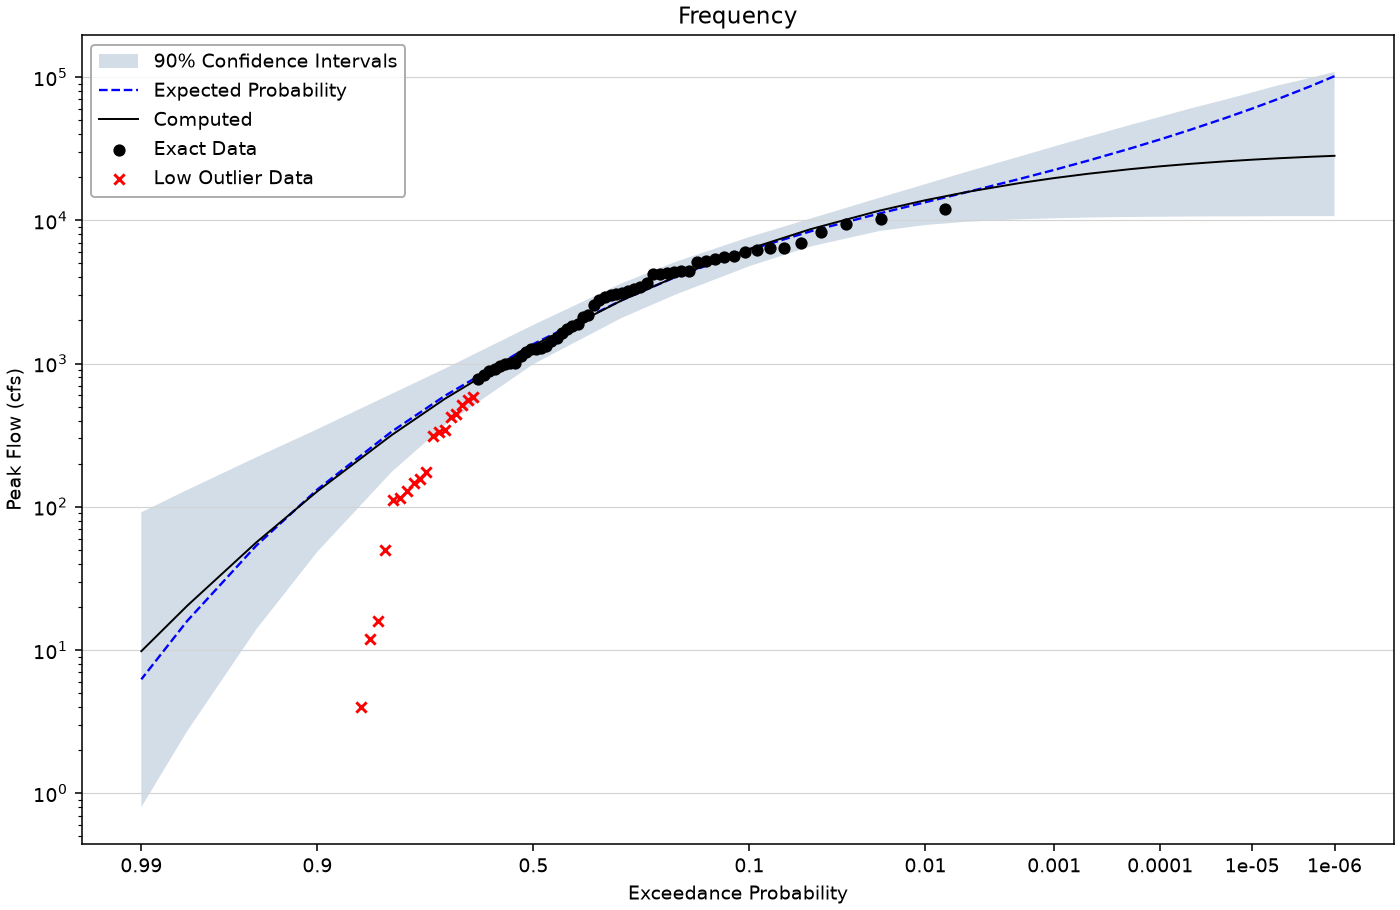

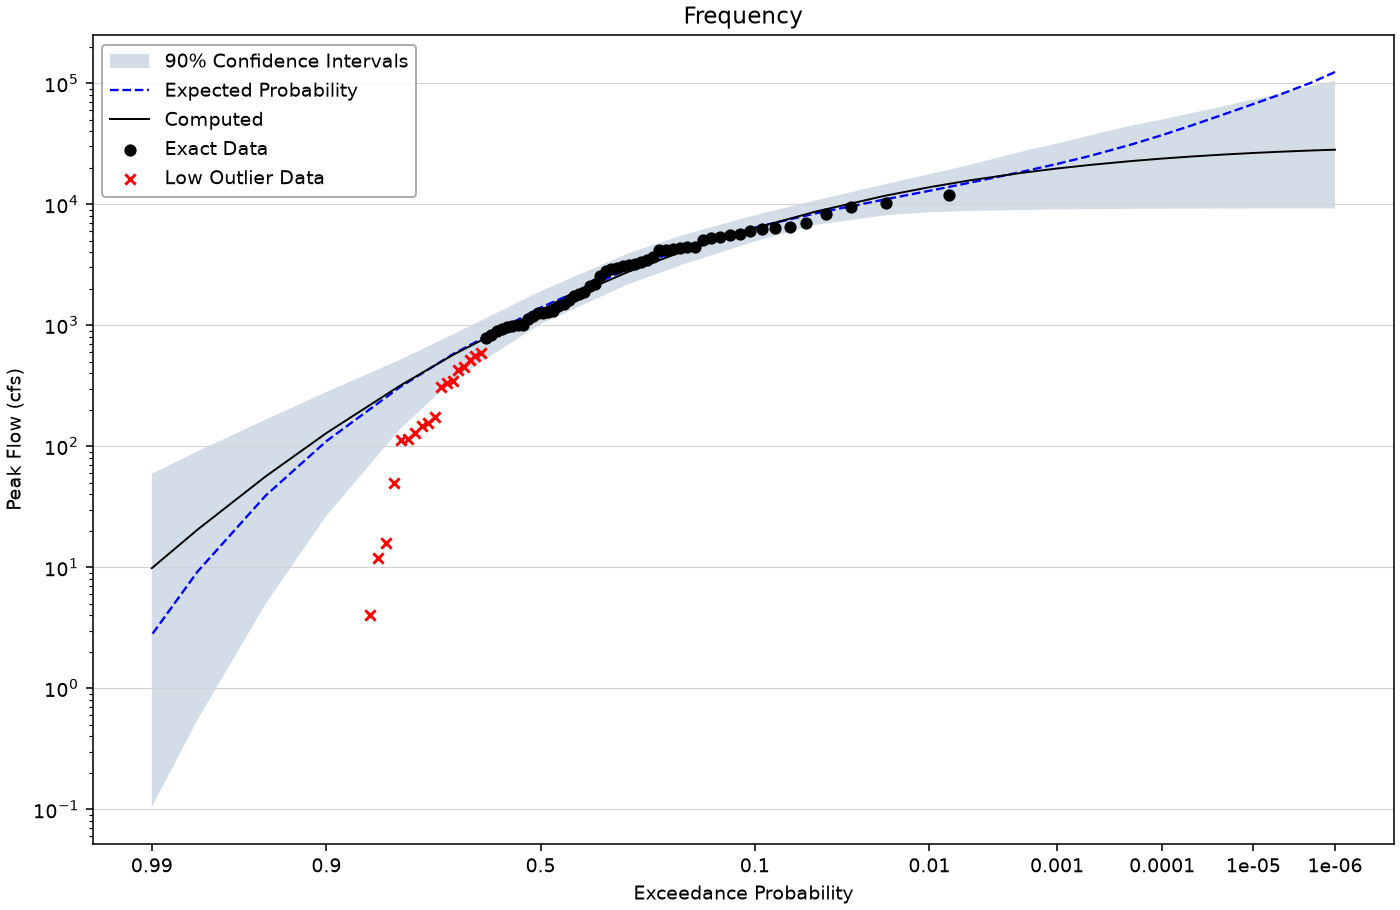

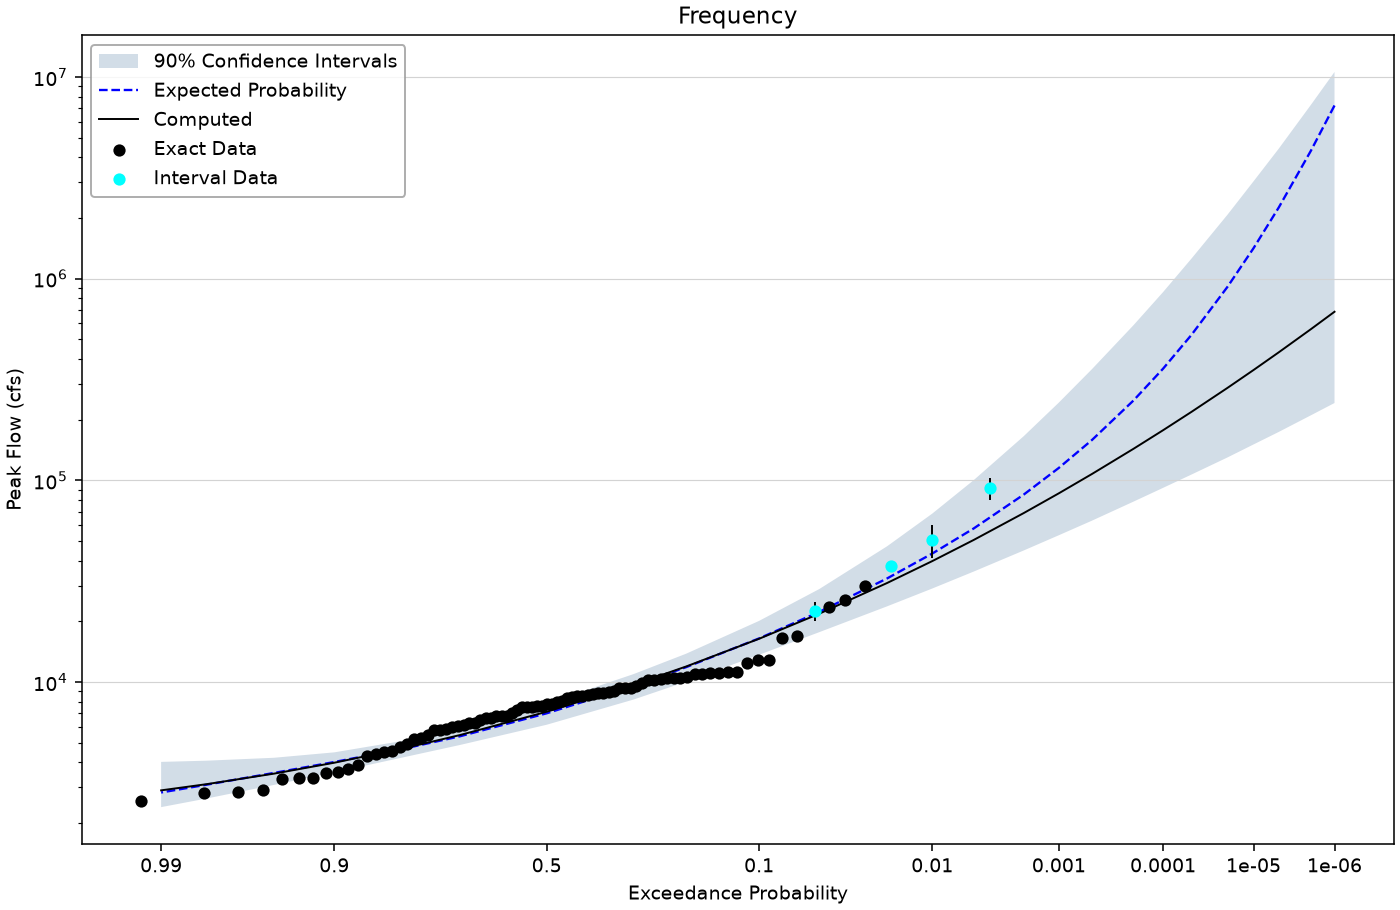

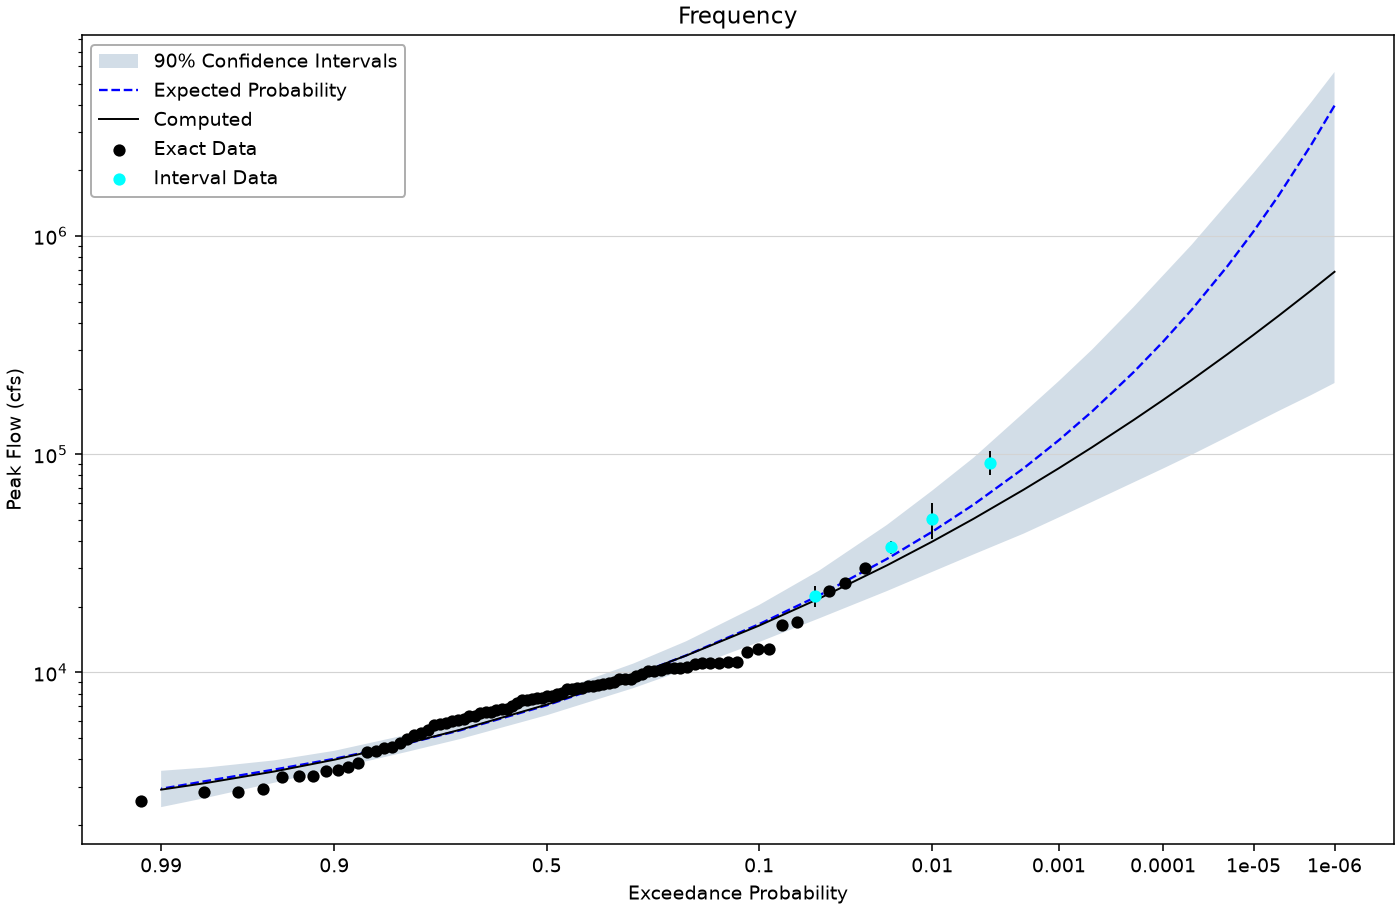

In [7]:
specs = {}
for name, input_name, _, _ in case_specs:
    context = plot_context(analyses[name], models[name], name=name, raw=raw,
                           frame=frames[input_name], metadata=raw["inputs"][input_name]["metadata"])
    specs[name] = plots(context)
    show(specs[name]["frequency"])

**Adapt this example:** retain exact zero flags, historical interval bounds
and perception windows, then select a GMM uncertainty method. Source:
England et al. (2019), Bulletin 17C, Appendix 10, USGS TM 4-B5.